# 1. Setup

In [1]:
# Utilities
import time
import warnings
warnings.filterwarnings("ignore")

# Dataframe
import numpy as np
import pandas as pd

# ML: Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.feature_selection import mutual_info_regression

# Bayesian Network: pgmpy
from pgmpy.models import DiscreteBayesianNetwork, NaiveBayes
from pgmpy.estimators import (
    TreeSearch, HillClimbSearch,
    MaximumLikelihoodEstimator, BayesianEstimator,
    K2, BDeu
)
from pgmpy.inference import VariableElimination

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff

# Saving models
import joblib

print("Core libraries loaded.")

Core libraries loaded.


In [2]:
# Constants
RANDOM_STATE = 8
np.random.seed(RANDOM_STATE)

TARGET_CONTINUOUS = 'ucla_total'
TARGET_DISCRETE = 'ucla_bin'
BN_TARGET_BINS = 3
TOP_N_FEATURES = 20
BN_BINS = 3
TEST_SIZE = 0.2

In [3]:
# Utilities
def format_time(seconds):
    hrs = int(seconds // 3600)
    mins = int((seconds % 3600) // 60)
    secs = seconds % 60
    parts = []
    if hrs: parts.append(f"{hrs}h")
    if mins: parts.append(f"{mins}m")
    parts.append(f"{secs:.2f}s")
    return " ".join(parts)

# 2. Dataset Loading & Preprocessing

In [4]:
DATA_PATH = "../../data/phase4.csv"

dataset = pd.read_csv(DATA_PATH)

# Select relevant columns
dataset = dataset[[
    'sex', 'age', 'married', 'child', 'hincome', 'pincome', 'job_group',
    'med_self', 'med_fam',
    'current_physical', 'past_physical', 'current_mental', 'past_mental',
    'current_covid19', 'past_covid19',
    'exercise', 'healthydiet', 'healthysleep', 'favoriteactivity',
    'interaction_offline', 'interaction_online',
    'pb_continuous', 'pb_altruistic', 'pb_avoidant', 'pb_understanding',
    'optimism', 'deteriorationeconomy', 'deteriorationinteract',
    'frustration', 'covidanxiety', 'covidsleepless',
    'difficultyliving', 'difficultywork',
    'k6_total', 'phq9_total', 'lsns6_total', 'sss8_total', 'shs_total',
    'ucla_total'
]]

print(f"Dataset loaded: {dataset.shape[0]} rows, {dataset.shape[1]} columns")
dataset.head()

Dataset loaded: 2659 rows, 39 columns


,sex,age,married,child,hincome,pincome,job_group,med_self,med_fam,current_physical,...,covidanxiety,covidsleepless,difficultyliving,difficultywork,k6_total,phq9_total,lsns6_total,sss8_total,shs_total,ucla_total
0,1.0,57.0,2.0,2.0,4.0,3.0,1.0,2.0,2.0,2.0,...,5.0,5.0,5.0,5.0,12.0,15.0,4.0,18.0,4.00,24.0
1,2.0,70.0,2.0,2.0,7.0,1.0,2.0,2.0,2.0,2.0,...,5.0,1.0,1.0,6.0,1.0,0.0,18.0,1.0,4.50,11.0
2,1.0,52.0,1.0,1.0,3.0,3.0,1.0,2.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,0.0,1.0,4.00,32.0
3,1.0,66.0,2.0,2.0,4.0,2.0,1.0,2.0,2.0,2.0,...,1.0,1.0,1.0,1.0,0.0,0.0,13.0,0.0,5.50,21.0
4,1.0,63.0,2.0,2.0,7.0,7.0,1.0,2.0,2.0,2.0,...,4.0,2.0,4.0,4.0,0.0,2.0,18.0,0.0,5.25,22.0


In [5]:
# Preprocessing
dataset_cleaned = dataset.copy()

# Fix hincome/pincome: replace invalid (10) and NaN with mode
for col in ['hincome', 'pincome']:
    mode_val = dataset_cleaned.loc[
        ~dataset_cleaned[col].isin([10]) & dataset_cleaned[col].notna(), col
    ].mode()[0]
    dataset_cleaned[col] = dataset_cleaned[col].replace([10], mode_val)
    dataset_cleaned[col] = dataset_cleaned[col].fillna(mode_val)

# Drop rows with remaining NaN
n_before = len(dataset_cleaned)
dataset_cleaned = dataset_cleaned.dropna()
print(f"Rows after NaN removal: {len(dataset_cleaned)} (dropped {n_before - len(dataset_cleaned)})")

# Remove outliers in hincome/pincome via IQR
n_before = len(dataset_cleaned)
Q1 = dataset_cleaned[['hincome', 'pincome']].quantile(0.25)
Q3 = dataset_cleaned[['hincome', 'pincome']].quantile(0.75)
IQR = Q3 - Q1
mask = ~(
    (dataset_cleaned[['hincome', 'pincome']] < Q1 - 1.5 * IQR) |
    (dataset_cleaned[['hincome', 'pincome']] > Q3 + 1.5 * IQR)
).any(axis=1)
dataset_cleaned = dataset_cleaned[mask].reset_index(drop=True)
print(f"Rows after outlier removal: {len(dataset_cleaned)} (dropped {n_before - len(dataset_cleaned)})")

Rows after NaN removal: 2659 (dropped 0)
Rows after outlier removal: 2539 (dropped 120)


In [6]:
# Discretize continuous UCLA target into bins for BN internal use
t33 = dataset_cleaned[TARGET_CONTINUOUS].quantile(0.333)
t67 = dataset_cleaned[TARGET_CONTINUOUS].quantile(0.667)

dataset_cleaned[TARGET_DISCRETE] = np.where(
    dataset_cleaned[TARGET_CONTINUOUS] <= t33, 0,
    np.where(dataset_cleaned[TARGET_CONTINUOUS] <= t67, 1, 2)
)

# Compute bin centers (mean UCLA score per bin) for mapping back to continuous
bin_centers = [
    dataset_cleaned.loc[dataset_cleaned[TARGET_DISCRETE] == b, TARGET_CONTINUOUS].mean()
    for b in range(BN_TARGET_BINS)
]

bin_label_names = {0: 'Low', 1: 'Medium', 2: 'High'}

print(f"UCLA score range: [{dataset_cleaned[TARGET_CONTINUOUS].min():.0f}, {dataset_cleaned[TARGET_CONTINUOUS].max():.0f}]")
print(f"UCLA score mean:  {dataset_cleaned[TARGET_CONTINUOUS].mean():.2f} (SD = {dataset_cleaned[TARGET_CONTINUOUS].std():.2f})")
print(f"UCLA score median: {dataset_cleaned[TARGET_CONTINUOUS].median():.1f}")
print(f"\nBN discretization thresholds: Low <= {t33:.0f}, Medium <= {t67:.0f}, High > {t67:.0f}")
print(f"Bin centers (mean UCLA per bin): {[f'{c:.2f}' for c in bin_centers]}")
print(f"\nBN bin distribution:")
print(dataset_cleaned[TARGET_DISCRETE].value_counts().sort_index().rename(index=bin_label_names))

UCLA score range: [10, 40]
UCLA score mean:  23.57 (SD = 5.98)
UCLA score median: 24.0

BN discretization thresholds: Low <= 21, Medium <= 25, High > 25
Bin centers (mean UCLA per bin): ['17.08', '23.92', '29.77']

BN bin distribution:
ucla_bin
Low       852
Medium    842
High      845
Name: count, dtype: int64


# 3. EDA

In [7]:
# Statistical summary
dataset_cleaned.describe()

,sex,age,married,child,hincome,pincome,job_group,med_self,med_fam,current_physical,...,covidsleepless,difficultyliving,difficultywork,k6_total,phq9_total,lsns6_total,sss8_total,shs_total,ucla_total,ucla_bin
count,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,...,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000,2539.000000
mean,1.425364,56.033478,1.630563,1.568334,2.929894,2.038992,1.752659,1.953131,1.953525,1.933832,...,2.155967,2.202836,2.332020,3.563214,3.455297,8.886963,4.765656,4.472627,23.569909,0.997243
std,0.494496,12.850356,0.482747,0.495406,1.663771,1.361861,1.245428,0.211400,0.210553,0.248624,...,1.384400,1.430907,1.518614,5.304168,5.491869,6.224920,5.414045,1.152412,5.983769,0.817697
min,1.000000,22.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,10.000000,0.000000
25%,1.000000,47.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,4.000000,20.000000,0.000000
50%,1.000000,56.000000,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000,2.000000,...,1.000000,1.000000,2.000000,1.000000,1.000000,9.000000,3.000000,4.500000,24.000000,1.000000
75%,2.000000,65.000000,2.000000,2.000000,4.000000,3.000000,2.000000,2.000000,2.000000,2.000000,...,4.000000,4.000000,4.000000,5.000000,5.000000,13.000000,7.000000,5.250000,26.000000,2.000000
max,2.000000,92.000000,2.000000,2.000000,7.000000,6.000000,5.000000,2.000000,2.000000,2.000000,...,7.000000,7.000000,7.000000,24.000000,27.000000,30.000000,32.000000,7.000000,40.000000,2.000000


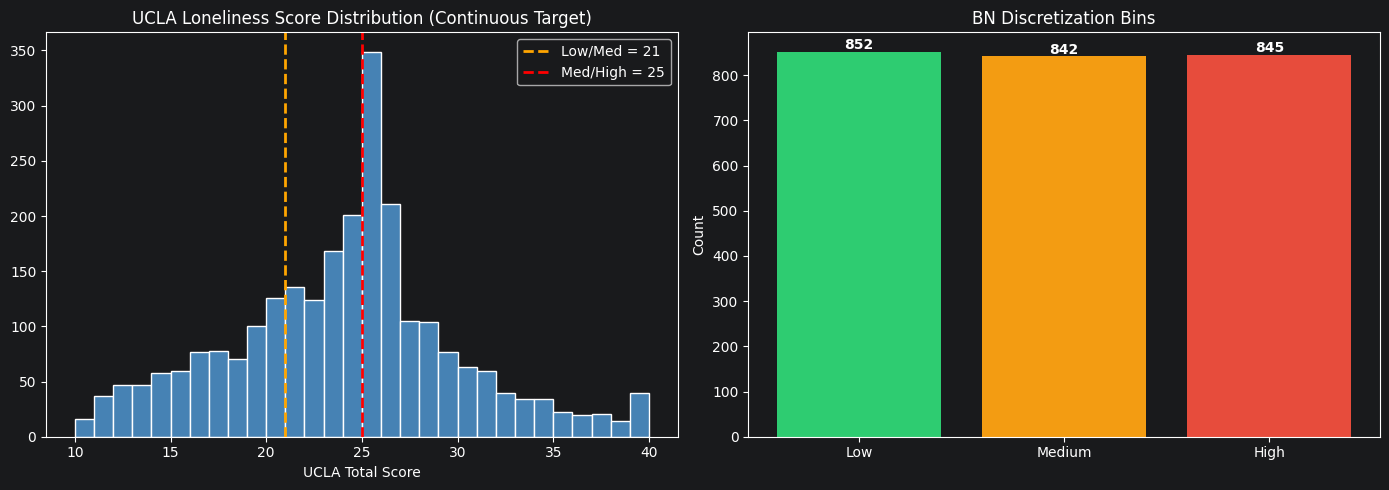

In [8]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Continuous UCLA distribution with bin thresholds
axes[0].hist(dataset_cleaned[TARGET_CONTINUOUS], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(t33, color='orange', linestyle='--', linewidth=2, label=f'Low/Med = {t33:.0f}')
axes[0].axvline(t67, color='red', linestyle='--', linewidth=2, label=f'Med/High = {t67:.0f}')
axes[0].set_title('UCLA Loneliness Score Distribution (Continuous Target)')
axes[0].set_xlabel('UCLA Total Score')
axes[0].legend()

# BN bin counts
counts = dataset_cleaned[TARGET_DISCRETE].value_counts().sort_index()
axes[1].bar([bin_label_names[i] for i in counts.index], counts.values,
            color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('BN Discretization Bins')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

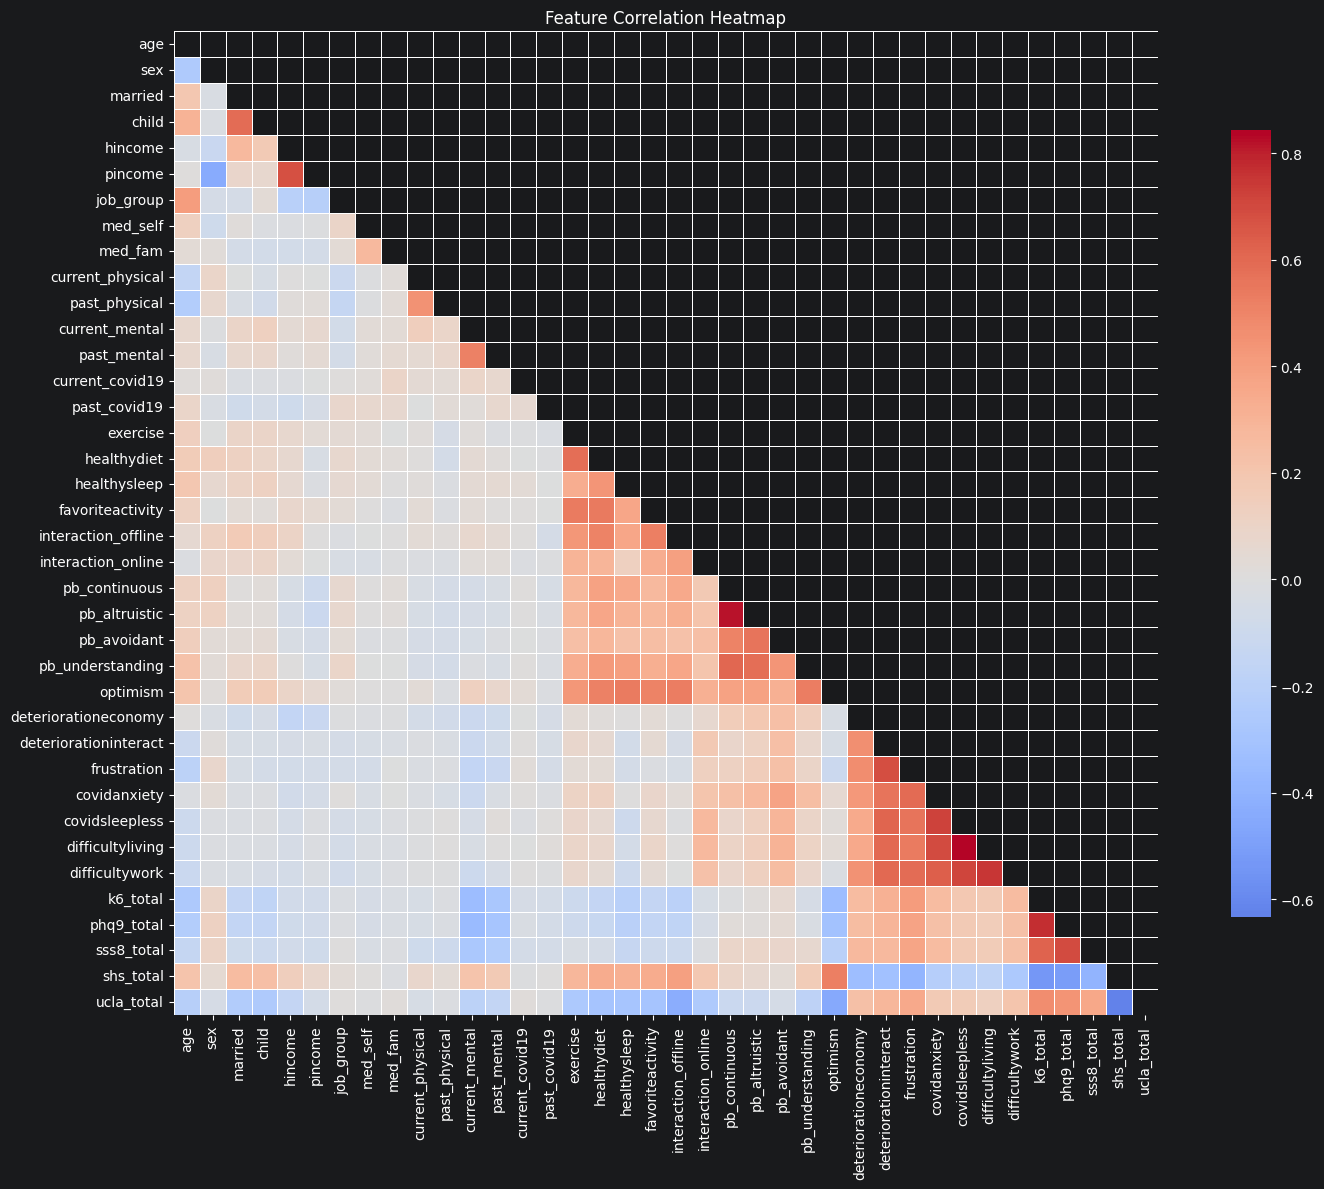

In [9]:
# Feature list (excluding targets)
feature_cols = [
    'age', 'sex', 'married', 'child', 'hincome', 'pincome', 'job_group',
    'med_self', 'med_fam', 'current_physical', 'past_physical',
    'current_mental', 'past_mental', 'current_covid19', 'past_covid19',
    'exercise', 'healthydiet', 'healthysleep', 'favoriteactivity',
    'interaction_offline', 'interaction_online',
    'pb_continuous', 'pb_altruistic', 'pb_avoidant', 'pb_understanding',
    'optimism', 'deteriorationeconomy', 'deteriorationinteract',
    'frustration', 'covidanxiety', 'covidsleepless',
    'difficultyliving', 'difficultywork',
    'k6_total', 'phq9_total', 'sss8_total', 'shs_total'
]

# Correlation heatmap
plt.figure(figsize=(16, 12))
corr = dataset_cleaned[feature_cols + [TARGET_CONTINUOUS]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

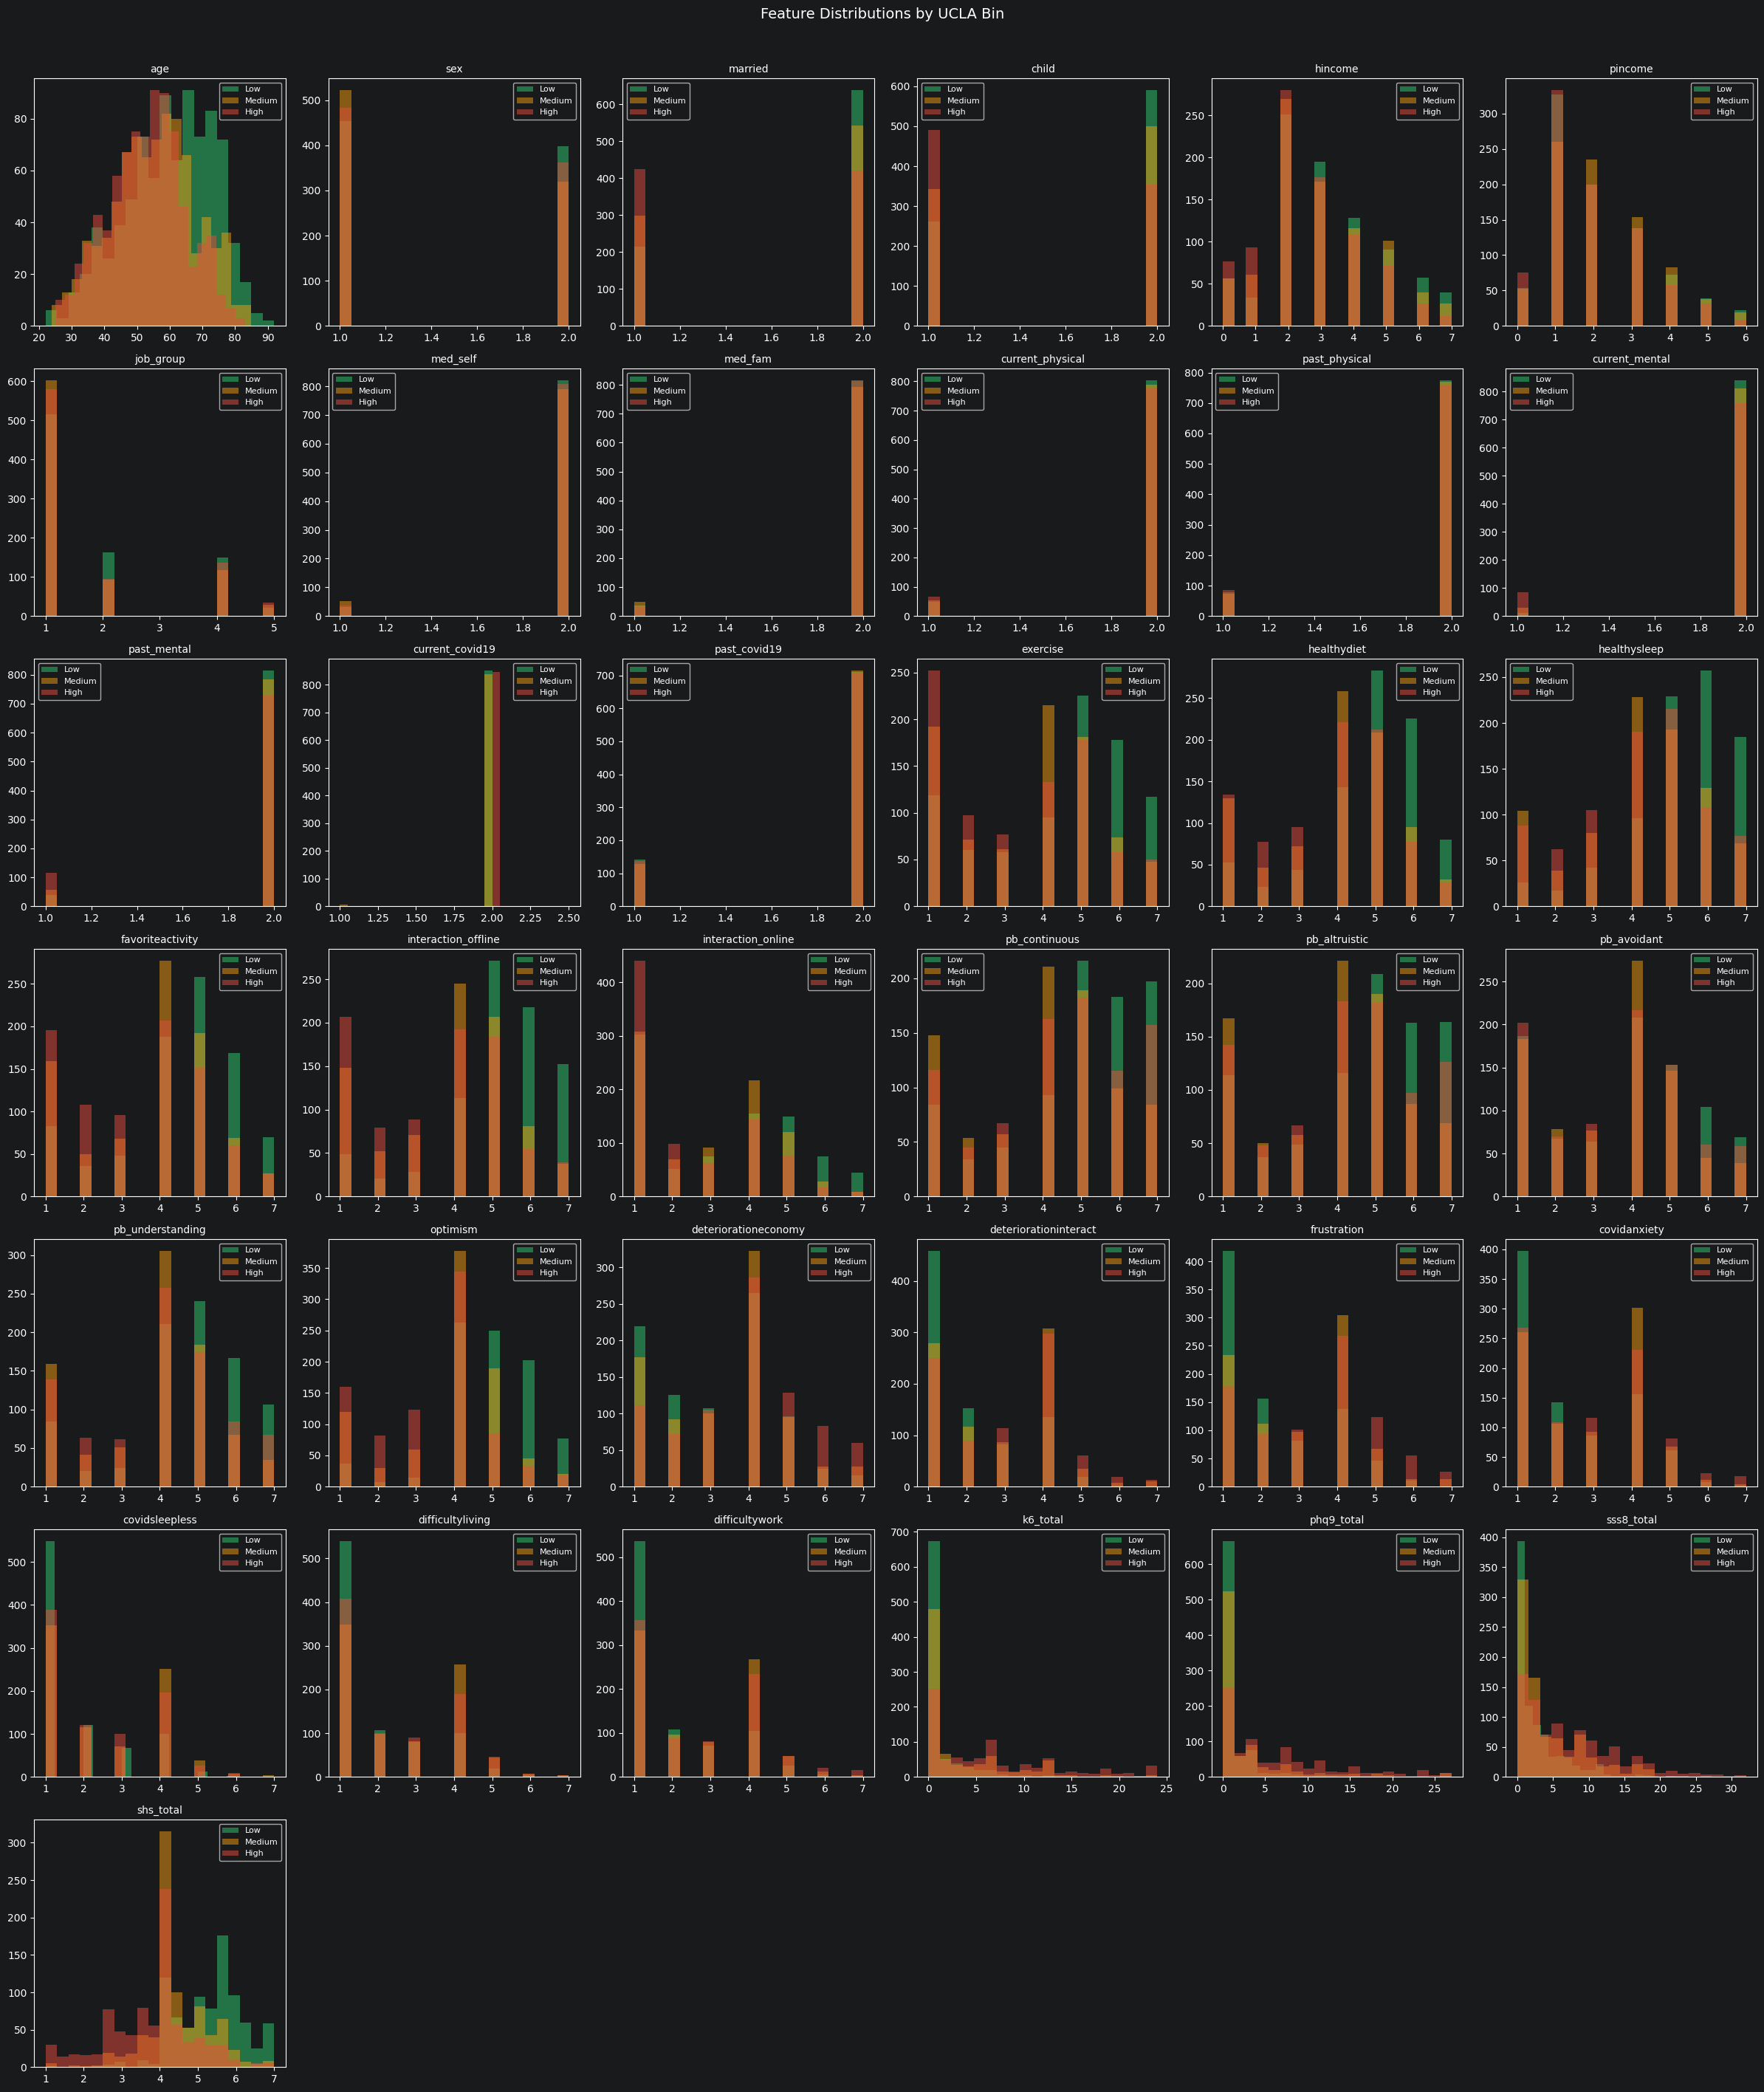

In [10]:
# Feature distributions by target bin
n_cols = 6
n_rows = (len(feature_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 4 * n_rows))
axes = axes.flatten()

colors_bins = ['#2ecc71', '#f39c12', '#e74c3c']
for i, feat in enumerate(feature_cols):
    if i < len(axes):
        for label in range(BN_TARGET_BINS):
            subset = dataset_cleaned[dataset_cleaned[TARGET_DISCRETE] == label][feat]
            axes[i].hist(subset, bins=20, alpha=0.5, color=colors_bins[label],
                        label=bin_label_names[label])
        axes[i].set_title(feat, fontsize=10)
        axes[i].legend(fontsize=8)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by UCLA Bin', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 4. Train-Test Split

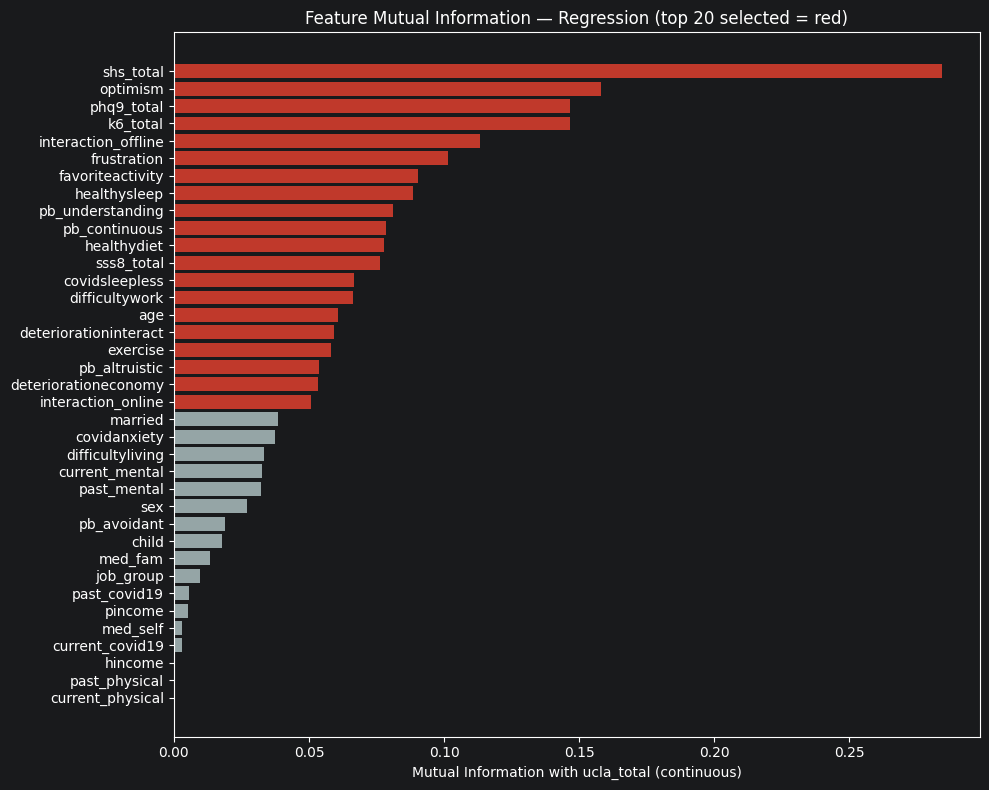


Selected features (20):
   1. shs_total                      MI = 0.2841
   2. optimism                       MI = 0.1580
   3. phq9_total                     MI = 0.1466
   4. k6_total                       MI = 0.1466
   5. interaction_offline            MI = 0.1132
   6. frustration                    MI = 0.1014
   7. favoriteactivity               MI = 0.0902
   8. healthysleep                   MI = 0.0884
   9. pb_understanding               MI = 0.0812
  10. pb_continuous                  MI = 0.0784
  11. healthydiet                    MI = 0.0779
  12. sss8_total                     MI = 0.0762
  13. covidsleepless                 MI = 0.0667
  14. difficultywork                 MI = 0.0663
  15. age                            MI = 0.0608
  16. deteriorationinteract          MI = 0.0593
  17. exercise                       MI = 0.0580
  18. pb_altruistic                  MI = 0.0539
  19. deteriorationeconomy           MI = 0.0534
  20. interaction_online             MI = 0.

In [11]:
# Feature selection via mutual information (regression)
X_full = dataset_cleaned[feature_cols].values
y_continuous = dataset_cleaned[TARGET_CONTINUOUS].values

mi_scores = mutual_info_regression(X_full, y_continuous, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'Feature': feature_cols, 'MI': mi_scores}).sort_values('MI', ascending=False)

selected_features = mi_df['Feature'].iloc[:TOP_N_FEATURES].tolist()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#c0392b' if f in selected_features else '#95a5a6' for f in mi_df['Feature']]
ax.barh(mi_df['Feature'], mi_df['MI'], color=colors)
ax.set_xlabel('Mutual Information with ucla_total (continuous)')
ax.set_title(f'Feature Mutual Information — Regression (top {TOP_N_FEATURES} selected = red)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nSelected features ({TOP_N_FEATURES}):")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f:<30s} MI = {mi_df.loc[mi_df['Feature']==f, 'MI'].values[0]:.4f}")

In [12]:
# 80/20 train-test split
X = dataset_cleaned[selected_features]
y = dataset_cleaned[TARGET_CONTINUOUS]
y_bin = dataset_cleaned[TARGET_DISCRETE]

X_train, X_test, y_train, y_test, y_bin_train, y_bin_test = train_test_split(
    X, y, y_bin, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set:  {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nTraining UCLA mean: {y_train.mean():.2f} (SD = {y_train.std():.2f})")
print(f"Test UCLA mean:     {y_test.mean():.2f} (SD = {y_test.std():.2f})")
print(f"\nTraining bin distribution:\n{y_bin_train.value_counts().sort_index().rename(index=bin_label_names)}")
print(f"\nTest bin distribution:\n{y_bin_test.value_counts().sort_index().rename(index=bin_label_names)}")

Training set: 2031 samples, 20 features
Testing set:  508 samples, 20 features

Training UCLA mean: 23.62 (SD = 6.02)
Test UCLA mean:     23.35 (SD = 5.84)

Training bin distribution:
ucla_bin
Low       685
Medium    665
High      681
Name: count, dtype: int64

Test bin distribution:
ucla_bin
Low       167
Medium    177
High      164
Name: count, dtype: int64


# 5. Baseline Model Training

In [13]:
def predict_bn_regression(model, X_test_df, target_col, bin_centers):
    """Predict continuous values using a BN with discretized target.

    Gets posterior P(bin | evidence) and computes weighted mean of bin centers.
    """
    y_prob_df = model.predict_probability(X_test_df)

    # Extract probability columns for each bin
    prob_cols = sorted([c for c in y_prob_df.columns if c.startswith(f"{target_col}_")])
    probs = y_prob_df[prob_cols].values

    # Weighted mean of bin centers
    centers = np.array(bin_centers)
    y_pred_continuous = probs @ centers

    return y_pred_continuous

In [14]:
# Discretize features for Bayesian Network models
df_train_bn = pd.concat([X_train, y_bin_train.rename(TARGET_DISCRETE)], axis=1).reset_index(drop=True)
df_test_bn = pd.concat([X_test, y_bin_test.rename(TARGET_DISCRETE)], axis=1).reset_index(drop=True)

discretizers = {}
for col in selected_features:
    n_unique = df_train_bn[col].nunique()
    if n_unique > BN_BINS:
        disc = KBinsDiscretizer(n_bins=BN_BINS, encode='ordinal', strategy='quantile')
        df_train_bn[col] = disc.fit_transform(df_train_bn[[col]]).astype(int).ravel()
        df_test_bn[col] = disc.transform(df_test_bn[[col]]).astype(int).ravel()
        discretizers[col] = disc
    else:
        le = LabelEncoder()
        df_train_bn[col] = le.fit_transform(df_train_bn[col])
        df_test_bn[col] = le.transform(df_test_bn[col])

# Ensure all columns are integer-typed for pgmpy
df_train_bn = df_train_bn.astype(int)
df_test_bn = df_test_bn.astype(int)

print("Feature value ranges after discretization:")
for col in selected_features:
    print(f"  {col:<30s}: {df_train_bn[col].nunique()} unique values")

Feature value ranges after discretization:
  shs_total                     : 3 unique values
  optimism                      : 3 unique values
  phq9_total                    : 2 unique values
  k6_total                      : 2 unique values
  interaction_offline           : 3 unique values
  frustration                   : 3 unique values
  favoriteactivity              : 3 unique values
  healthysleep                  : 3 unique values
  pb_understanding              : 3 unique values
  pb_continuous                 : 3 unique values
  healthydiet                   : 3 unique values
  sss8_total                    : 3 unique values
  covidsleepless                : 2 unique values
  difficultywork                : 2 unique values
  age                           : 3 unique values
  deteriorationinteract         : 2 unique values
  exercise                      : 3 unique values
  pb_altruistic                 : 3 unique values
  deteriorationeconomy          : 3 unique values
  inter

In [15]:
# Build BN model structures

# --- 1. Naive Bayes BN ---
# Build as regular DiscreteBayesianNetwork with NB structure (target -> each feature)
nb_edges = [(TARGET_DISCRETE, feat) for feat in selected_features]
nb_model = DiscreteBayesianNetwork(nb_edges)
nb_model.fit(df_train_bn, estimator=MaximumLikelihoodEstimator)
print("Naive Bayes BN structure built.")

# --- 2. TAN (Tree-Augmented Naive Bayes) ---
# root_node must be a feature node (not the class node)
tan_root = selected_features[0]
tan_search = TreeSearch(df_train_bn, root_node=tan_root)
tan_dag = tan_search.estimate(estimator_type="tan", class_node=TARGET_DISCRETE)
tan_model = DiscreteBayesianNetwork(tan_dag.edges())
tan_model.fit(df_train_bn, estimator=MaximumLikelihoodEstimator)
print("TAN BN structure built.")

# --- 3. Hill Climb Search BN ---
hc_search = HillClimbSearch(df_train_bn)
hc_dag = hc_search.estimate(scoring_method=K2(df_train_bn))
hc_model = DiscreteBayesianNetwork(hc_dag.edges())
hc_model.fit(df_train_bn, estimator=MaximumLikelihoodEstimator)
print("Hill Climb BN structure built.")

# --- 4. Hill Climb BN with BDeu scoring ---
hc_search_bdeu = HillClimbSearch(df_train_bn)
hc_dag_bdeu = hc_search_bdeu.estimate(scoring_method=BDeu(df_train_bn))
hc_model_bdeu = DiscreteBayesianNetwork(hc_dag_bdeu.edges())
hc_model_bdeu.fit(df_train_bn, estimator=MaximumLikelihoodEstimator)
print("Hill Climb BN (BDeu) structure built.")

Naive Bayes BN structure built.


Building tree: 100%|██████████| 210/210.0 [00:01<00:00, 127.49it/s]


TAN BN structure built.


  0%|          | 51/1000000 [00:01<8:57:19, 31.02it/s] 


Hill Climb BN structure built.


  0%|          | 46/1000000 [00:01<9:11:34, 30.21it/s] 


Hill Climb BN (BDeu) structure built.


In [16]:
# Train and evaluate all baseline models
X_test_bn = df_test_bn[selected_features]
y_test_values = y_test.values

bn_models = [
    ("Naive Bayes BN", nb_model),
    ("TAN BN", tan_model),
    ("Hill Climb BN (K2)", hc_model),
    ("Hill Climb BN (BDeu)", hc_model_bdeu),
]

results = []
trained_models = {}
predictions = {}

for name, model in bn_models:
    print(f"\n{'='*60}")
    print(f"  {name} (baseline)")
    print(f"{'='*60}")

    start_test = time.time()
    y_pred = predict_bn_regression(model, X_test_bn, TARGET_DISCRETE, bin_centers)
    test_time = time.time() - start_test

    r2 = r2_score(y_test_values, y_pred)
    mae = mean_absolute_error(y_test_values, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_values, y_pred))

    print(f"  R2 Score: {r2:.4f}")
    print(f"  MAE:      {mae:.4f}")
    print(f"  RMSE:     {rmse:.4f}")
    print(f"  Predict:  {format_time(test_time)}")

    results.append({
        "Model": name, "R2": r2, "MAE": mae,
        "RMSE": rmse, "Test Time (s)": test_time
    })
    trained_models[name] = model
    predictions[name] = y_pred

df_results = pd.DataFrame(results)
print("\n" + "="*60)
print("  All baseline models trained.")
print("="*60)


  Naive Bayes BN (baseline)
  R2 Score: 0.3186
  MAE:      3.7691
  RMSE:     4.8152
  Predict:  0.42s

  TAN BN (baseline)
  R2 Score: 0.3951
  MAE:      3.5130
  RMSE:     4.5370
  Predict:  0.52s

  Hill Climb BN (K2) (baseline)
  R2 Score: 0.4276
  MAE:      3.4469
  RMSE:     4.4134
  Predict:  0.51s

  Hill Climb BN (BDeu) (baseline)
  R2 Score: 0.4096
  MAE:      3.5388
  RMSE:     4.4819
  Predict:  0.49s

  All baseline models trained.


# 6. Results & Comparison

In [21]:
# Results table
display(df_results.sort_values('R2', ascending=False))

,Model,R2,MAE,RMSE,Test Time (s)
2,Hill Climb BN (K2),0.427575,3.446900,4.413366,0.512602
3,Hill Climb BN (BDeu),0.409647,3.538768,4.481946,0.494356
1,TAN BN,0.395058,3.513022,4.536989,0.522487
0,Naive Bayes BN,0.318602,3.769109,4.815167,0.415605


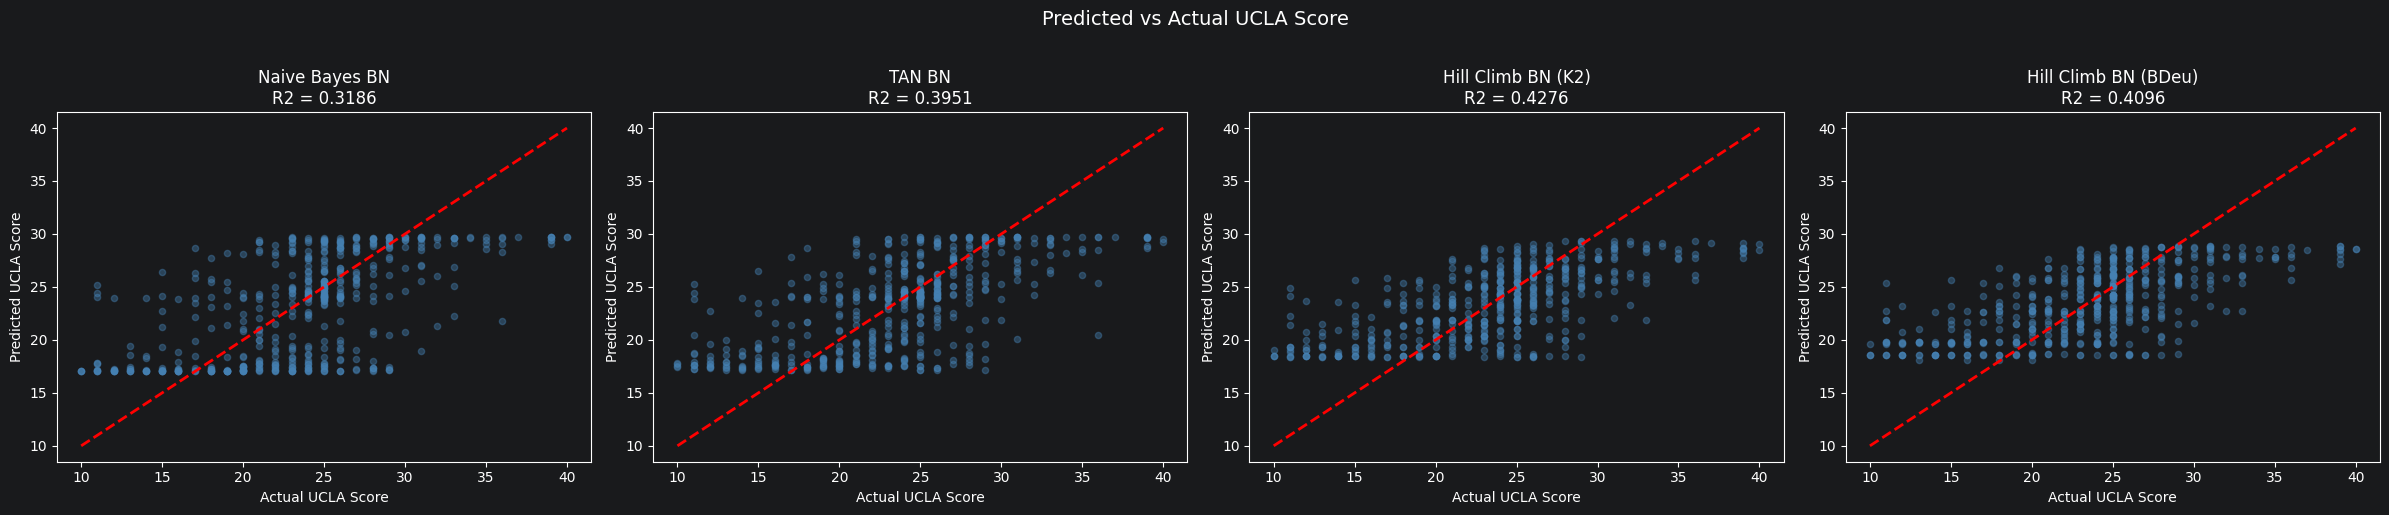

In [22]:
# Scatter plots: Predicted vs Actual
n_models = len(predictions)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test_values, y_pred, alpha=0.4, s=20, color='steelblue')
    min_val = min(y_test_values.min(), y_pred.min())
    max_val = max(y_test_values.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    ax.set_xlabel('Actual UCLA Score')
    ax.set_ylabel('Predicted UCLA Score')
    r2 = r2_score(y_test_values, y_pred)
    ax.set_title(f'{name}\nR2 = {r2:.4f}')

plt.suptitle('Predicted vs Actual UCLA Score', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

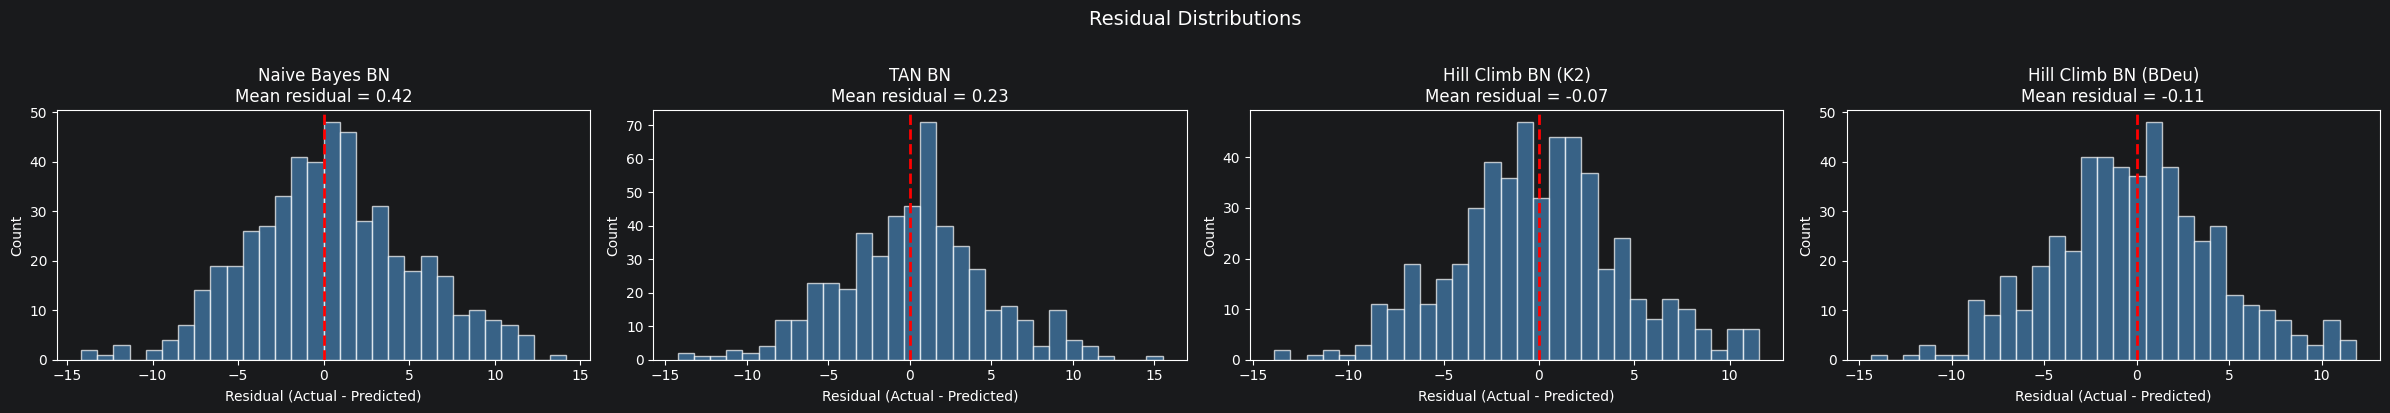

In [23]:
# Residual distributions
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, predictions.items()):
    residuals = y_test_values - y_pred
    ax.hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Residual (Actual - Predicted)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name}\nMean residual = {residuals.mean():.2f}')

plt.suptitle('Residual Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 7. Save Models & Results

In [24]:
# Save all baseline models
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_")
    save_path = f"models/bn_regression_baseline_{safe_name}.joblib"
    joblib.dump(model, save_path)
    print(f"Saved: {save_path}")

# Save results
df_results.to_csv("models/bn_regression_baseline_results.csv", index=False)
print("\nBaseline comparison results saved to models/bn_regression_baseline_results.csv")

# Save discretizers and bin centers
joblib.dump(discretizers, "models/bn_regression_discretizers.joblib")
joblib.dump(bin_centers, "models/bn_regression_bin_centers.joblib")
print("Discretizers and bin centers saved.")

Saved: models/bn_regression_baseline_naive_bayes_bn.joblib
Saved: models/bn_regression_baseline_tan_bn.joblib
Saved: models/bn_regression_baseline_hill_climb_bn_k2.joblib
Saved: models/bn_regression_baseline_hill_climb_bn_bdeu.joblib

Baseline comparison results saved to models/bn_regression_baseline_results.csv
Discretizers and bin centers saved.
